In [1]:
import pandas as pd
import torch as t
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import dataclasses
import re
import pathlib
from tqdm import tqdm

In [31]:
@dataclasses.dataclass
class DataSetConfig:
    data: str
    title: str
    metrics: str
    e_regexp: re.Pattern


globs: dict[str, DataSetConfig] = {
    "syn": DataSetConfig(
        data="demo_syn/syn_no_1_*.csv",
        title="Synthetic Data",
        metrics="metric_results/syn_no_1_*.csv",
        e_regexp=re.compile(r"syn_no_1_(.*).csv"),
    ),
    "privbayes": DataSetConfig(
        data="Data/privbayes(e=*).csv",
        title="PrivBayes Data",
        metrics="metric_results/privbayes(e=*)*.csv",
        e_regexp=re.compile(r"privbayes\(e=([^\)]*)\).*.csv"),
    ),
}

In [32]:
def load_data(
    config: DataSetConfig, root_path: pathlib.Path = pathlib.Path("../"), index_col=0
) -> pd.DataFrame:
    all_files = glob.glob(str(root_path / config.data))
    metric_files = glob.glob(str(root_path / config.metrics))
    print(
        f"Loading {len(all_files)} data files and {len(metric_files)} metric files for {config.title}"
    )
    df_list = []
    for filename in all_files:
        e_match = config.e_regexp.search(filename)
        if e_match:
            epsilon = e_match.group(1)
        else:
            epsilon = "N/A"
        df = pd.read_csv(filename, index_col=index_col)
        df["epsilon"] = epsilon
        df_list.append(df)
    combined_df = pd.concat(df_list, ignore_index=True)

    # load metrics
    metric_list = []
    for filename in metric_files:
        e_match = config.e_regexp.search(filename)
        if e_match:
            epsilon = e_match.group(1)
        else:
            epsilon = "N/A"
        metric_df = pd.read_csv(filename, index_col=None).T
        metric_df.columns = metric_df.iloc[0]
        metric_df = metric_df[1:]
        # convert columns to numeric
        metric_df = metric_df.apply(pd.to_numeric, errors="ignore")
        metric_df["epsilon"] = epsilon
        metric_list.append(metric_df)
    combined_metrics = pd.concat(metric_list, ignore_index=True)

    # join the tables
    combined_df = combined_df.merge(combined_metrics, on="epsilon", how="right")
    combined_df["epsilon"] = combined_df["epsilon"].map(
        lambda x: float(x) if x != "N/A" else np.nan
    )
    return combined_df


data_syn = load_data(globs["syn"], index_col=0)
data_privbayes = load_data(globs["privbayes"], index_col=None)

Loading 125 data files and 100 metric files for Synthetic Data
Loading 106 data files and 100 metric files for PrivBayes Data


In [33]:
data_syn.describe()

,Height,Like Liquorice,Times Visited Italy,First Time London,Steps per Day,epsilon,Attribute Inference Risk,GeneralizedCAP,ZeroCAP,Median Distance to Closest Record,...,Common Row Proportion,Nearest Synthetic Neighbour Distance,Close Value Probability,Distant Value Probability,Authenticity,DetectionMLP,Identifiability Score,Distance to Closest Record,Nearest Neighbour Distance Ratio,Hidden Rate
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.00000,150000.000000,150000.0,150000.000000,...,150000.0,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.0000,150000.0
mean,170.065476,0.424587,1.821467,0.297313,8032.582640,0.918247,0.67720,0.538600,0.0,0.241100,...,0.0,0.590600,0.206000,0.95620,0.395200,0.048000,0.417500,0.766100,0.3324,0.0
std,10.460656,0.494282,1.742217,0.457077,3051.658695,1.235061,0.02117,0.057568,0.0,0.035969,...,0.0,0.012151,0.026608,0.00525,0.115009,0.037041,0.070744,0.012157,0.0068,0.0
min,137.390000,0.000000,0.000000,0.000000,1000.000000,0.020000,0.60000,0.430000,0.0,0.120000,...,0.0,0.550000,0.110000,0.94000,0.110000,0.000000,0.180000,0.710000,0.3100,0.0
25%,162.900000,0.000000,0.000000,0.000000,5884.000000,0.079550,0.67000,0.500000,0.0,0.237500,...,0.0,0.580000,0.190000,0.95000,0.330000,0.020000,0.370000,0.760000,0.3300,0.0
50%,170.220000,0.000000,1.000000,0.000000,7955.000000,0.316351,0.68000,0.520000,0.0,0.260000,...,0.0,0.590000,0.210000,0.96000,0.455000,0.040000,0.450000,0.770000,0.3300,0.0
75%,177.070000,1.000000,3.000000,1.000000,10195.000000,1.257804,0.69000,0.560000,0.0,0.260000,...,0.0,0.600000,0.222500,0.96000,0.480000,0.070000,0.470000,0.770000,0.3400,0.0
max,206.830000,1.000000,6.000000,1.000000,17294.000000,5.000000,0.72000,0.680000,0.0,0.270000,...,0.0,0.620000,0.260000,0.97000,0.510000,0.160000,0.500000,0.790000,0.3500,0.0


In [34]:
data_privbayes

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Common Row Proportion,Nearest Synthetic Neighbour Distance,Close Value Probability,Distant Value Probability,Authenticity,DetectionMLP,Identifiability Score,Distance to Closest Record,Nearest Neighbour Distance Ratio,Hidden Rate
0,3.0,21.50000,0.0,84.25,14.0,934.87040,0.003947,0.002500,10.397600,0.6,...,0.0,0.94,0.99,1.0,0.11,0.02,0.11,0.80,0.33,0.0
1,9.0,69.12500,0.0,46.00,15.0,180.16667,0.007123,0.012948,0.252722,1.0,...,0.0,0.94,0.99,1.0,0.11,0.02,0.11,0.80,0.33,0.0
2,1.0,175.33333,0.0,145.50,6.0,1556.60000,0.009740,0.200000,17.533617,0.0,...,0.0,0.94,0.99,1.0,0.11,0.02,0.11,0.80,0.33,0.0
3,9.0,194.03622,6.0,19.60,14.0,566.50000,0.042146,0.010692,27.238663,0.6,...,0.0,0.94,0.99,1.0,0.11,0.02,0.11,0.80,0.33,0.0
4,0.0,63.25000,0.0,909.00,43.0,724.76666,0.004511,0.095238,0.000000,0.0,...,0.0,0.94,0.99,1.0,0.11,0.02,0.11,0.80,0.33,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1109695,0.0,0.00000,0.0,56.50,1.0,244.66667,0.018056,0.022424,0.000000,0.0,...,0.0,0.94,0.99,1.0,0.11,0.03,0.11,0.78,0.33,0.0
1109696,1.0,40.00000,0.0,0.00,21.0,49.00000,0.000000,0.026599,0.000000,0.0,...,0.0,0.94,0.99,1.0,0.11,0.03,0.11,0.78,0.33,0.0
1109697,0.0,29.20000,0.0,218.25,56.0,347.91666,0.000071,0.031399,0.000000,0.0,...,0.0,0.94,0.99,1.0,0.11,0.03,0.11,0.78,0.33,0.0
1109698,0.0,103.30000,0.0,0.00,25.0,59.25000,0.001053,0.018229,28.034527,0.0,...,0.0,0.94,0.99,1.0,0.11,0.03,0.11,0.78,0.33,0.0


In [35]:
data = data_privbayes

In [36]:
input_cols = data.columns.to_list()[-17:]
output_cols = data.columns.to_list()[:-18]
eps_col = "epsilon"
input_cols, output_cols

data_reorded = data[[eps_col] + input_cols + output_cols]
input_cols, output_cols

(['Attribute Inference Risk',
  'GeneralizedCAP',
  'ZeroCAP',
  'Median Distance to Closest Record',
  'Hitting Rate',
  'Membership Inference Risk',
  'Nearest Neighbour Adversarial Accuracy',
  'Common Row Proportion',
  'Nearest Synthetic Neighbour Distance',
  'Close Value Probability',
  'Distant Value Probability',
  'Authenticity',
  'DetectionMLP',
  'Identifiability Score',
  'Distance to Closest Record',
  'Nearest Neighbour Distance Ratio',
  'Hidden Rate'],
 ['Administrative',
  'Administrative_Duration',
  'Informational',
  'Informational_Duration',
  'ProductRelated',
  'ProductRelated_Duration',
  'BounceRates',
  'ExitRates',
  'PageValues',
  'SpecialDay',
  'Month',
  'OperatingSystems',
  'Browser',
  'Region',
  'TrafficType',
  'VisitorType',
  'Weekend',
  'Revenue'])

In [37]:
data_reorded

,epsilon,Attribute Inference Risk,GeneralizedCAP,ZeroCAP,Median Distance to Closest Record,Hitting Rate,Membership Inference Risk,Nearest Neighbour Adversarial Accuracy,Common Row Proportion,Nearest Synthetic Neighbour Distance,...,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,10.397600,0.6,May,2,2,4,2,New_Visitor,False,False
1,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,0.252722,1.0,May,3,2,8,13,Returning_Visitor,True,False
2,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,17.533617,0.0,May,2,2,6,3,New_Visitor,True,False
3,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,27.238663,0.6,June,2,2,8,2,Returning_Visitor,True,False
4,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,0.000000,0.0,Dec,1,1,2,2,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1109695,3.578000,0.84,0.77,0.0,0.17,0.00,0.02,0.29,0.0,0.94,...,0.000000,0.0,Aug,2,7,1,2,Returning_Visitor,False,False
1109696,3.578000,0.84,0.77,0.0,0.17,0.00,0.02,0.29,0.0,0.94,...,0.000000,0.0,Nov,2,2,1,5,New_Visitor,False,False
1109697,3.578000,0.84,0.77,0.0,0.17,0.00,0.02,0.29,0.0,0.94,...,0.000000,0.0,May,4,1,6,3,Returning_Visitor,False,False
1109698,3.578000,0.84,0.77,0.0,0.17,0.00,0.02,0.29,0.0,0.94,...,28.034527,0.0,Mar,5,3,3,9,Returning_Visitor,False,False


In [38]:
# one-hot encode categorical variables if needed
cat_features =data_reorded.columns[(data_reorded.dtypes == "object") | (data_reorded.dtypes == "category")].to_list()
data_encoded = pd.get_dummies(data_reorded, columns=cat_features, drop_first=True, )
data_encoded

,epsilon,Attribute Inference Risk,GeneralizedCAP,ZeroCAP,Median Distance to Closest Record,Hitting Rate,Membership Inference Risk,Nearest Neighbour Adversarial Accuracy,Common Row Proportion,Nearest Synthetic Neighbour Distance,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,0,0,0,0,1,0,0,0,0,0
1,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,0,0,0,0,1,0,0,0,0,1
2,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,0,0,0,0,1,0,0,0,0,0
3,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,0,0,1,0,0,0,0,0,0,1
4,3.026742,0.86,0.78,0.0,0.17,0.01,0.02,0.35,0.0,0.94,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1109695,3.578000,0.84,0.77,0.0,0.17,0.00,0.02,0.29,0.0,0.94,...,0,0,0,0,0,0,0,0,0,1
1109696,3.578000,0.84,0.77,0.0,0.17,0.00,0.02,0.29,0.0,0.94,...,0,0,0,0,0,1,0,0,0,0
1109697,3.578000,0.84,0.77,0.0,0.17,0.00,0.02,0.29,0.0,0.94,...,0,0,0,0,1,0,0,0,0,1
1109698,3.578000,0.84,0.77,0.0,0.17,0.00,0.02,0.29,0.0,0.94,...,0,0,0,1,0,0,0,0,0,1


In [39]:
input_cols= data_encoded.columns.to_list()[1:18]
output_cols= data_encoded.columns.to_list()[18:]
input_cols, output_cols

(['Attribute Inference Risk',
  'GeneralizedCAP',
  'ZeroCAP',
  'Median Distance to Closest Record',
  'Hitting Rate',
  'Membership Inference Risk',
  'Nearest Neighbour Adversarial Accuracy',
  'Common Row Proportion',
  'Nearest Synthetic Neighbour Distance',
  'Close Value Probability',
  'Distant Value Probability',
  'Authenticity',
  'DetectionMLP',
  'Identifiability Score',
  'Distance to Closest Record',
  'Nearest Neighbour Distance Ratio',
  'Hidden Rate'],
 ['Administrative',
  'Administrative_Duration',
  'Informational',
  'Informational_Duration',
  'ProductRelated',
  'ProductRelated_Duration',
  'BounceRates',
  'ExitRates',
  'PageValues',
  'SpecialDay',
  'OperatingSystems',
  'Browser',
  'Region',
  'TrafficType',
  'Weekend',
  'Revenue',
  'Month_Dec',
  'Month_Feb',
  'Month_Jul',
  'Month_June',
  'Month_Mar',
  'Month_May',
  'Month_Nov',
  'Month_Oct',
  'Month_Sep',
  'VisitorType_Other',
  'VisitorType_Returning_Visitor'])

In [40]:
class MLPNetwork(nn.Module):
    def __init__(self, input_size=len(input_cols), output_size=len(output_cols), hidden_size=64, hidden_layers=2, activation=nn.ReLU):
        super(MLPNetwork, self).__init__()
        self.in_layer = nn.Linear(input_size, hidden_size)
        self.hidden_layers = nn.ModuleList()
        for _ in range(hidden_layers - 1):
            self.hidden_layers.append(nn.Linear(hidden_size, hidden_size))
        self.out_layer = nn.Linear(hidden_size, output_size)
        self.activation = activation()
        self.in_norm = nn.BatchNorm1d(input_size)
        self.out_norm= nn.BatchNorm1d(output_size)
        
    def forward(self, x):
        x = self.in_norm(x)
        x = self.activation(self.in_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.out_norm(self.out_layer(x))
        return x
    
import torch.utils.data as data_utils
from tqdm import tqdm

In [41]:
# device = "cuda" if t.cuda.is_available() else "mps" if t.backends.mps.is_available() else "cpu"
# print(f"Using device: {device}")
# network = MLPNetwork(
#     input_size=len(input_cols),
#     output_size=len(output_cols),
#     hidden_size=128,
#     hidden_layers=4,
#     activation=nn.ReLU,
# ).to(device)
# optimizer = optim.Adam(network.parameters(), lr=0.01)
# criterion = nn.MSELoss()
# network.train()
# inputs = t.tensor(cleaned[input_cols].values, dtype=t.float32)
# targets = t.tensor(cleaned[output_cols].values, dtype=t.float32)
# dataset = data_utils.TensorDataset(inputs, targets)
# dataloader = data_utils.DataLoader(dataset, batch_size=128, shuffle=True)
# epochs = 10
# for epoch in range(epochs):
#     gen=tqdm(dataloader)
#     for batch_inputs, batch_targets in gen:
#         optimizer.zero_grad()
#         outputs = network(batch_inputs.to(device))
#         loss = criterion(outputs, batch_targets.to(device))
#         loss.backward()
#         optimizer.step()
#         gen.set_description(f"Epoch {epoch+1}/{epochs}")
#         gen.set_postfix(loss=loss.item())
#     print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')

In [42]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
X = data_encoded[input_cols].values
y = data_encoded[output_cols].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [43]:
model_ensemble: dict[str, lgb.LGBMRegressor] = {}

for i, output_col in enumerate(tqdm(output_cols)):
    model = lgb.LGBMRegressor(
        # n_estimators=1000,
        # learning_rate=0.01,
        # num_leaves=31,
        # max_depth=-1,
        # random_state=42,
        verbosity=-1
    )
    model.fit(
        X_train,
        y_train[:, i],
        eval_set=[(X_val, y_val[:, i])],
        # early_stopping_rounds=50,
        # verbose=False,
    )
    model_ensemble[output_col] = model
    print(f"Trained model for {output_col}")

  4%|▎         | 1/27 [00:01<00:47,  1.84s/it]

Trained model for Administrative


  7%|▋         | 2/27 [00:03<00:45,  1.83s/it]

Trained model for Administrative_Duration


 11%|█         | 3/27 [00:05<00:44,  1.84s/it]

...

Trained model for Month_Sep


 96%|█████████▋| 26/27 [00:48<00:01,  1.95s/it]

Trained model for VisitorType_Other


100%|██████████| 27/27 [00:50<00:00,  1.89s/it]

Trained model for VisitorType_Returning_Visitor


In [11]:
output_col

'Technical thermal expansion (1/K)(20.0-300.0�C)'

In [44]:
for output_col, model in model_ensemble.items():
    y_pred = model.predict(X_val)
    col_name=output_col.encode('ascii','ignore').decode("ascii")
    col_name = col_name.replace(" ", "_")
    col_name = col_name.replace(".", "_")   
    col_name = col_name.replace("/", "_")   
    mse = np.mean((y_pred - y_val[:, output_cols.index(output_col)]) ** 2)
    print(f"Validation MSE for {output_col}: {mse:.4f}")
    model.booster_.save_model(f"../inter/models/{col_name}_model.txt")
    

/Users/benedikt/tugraz/cgv/hereditary/PrivEval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Validation MSE for Administrative: 38.7668


/Users/benedikt/tugraz/cgv/hereditary/PrivEval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Validation MSE for Administrative_Duration: 73396.3765


/Users/benedikt/tugraz/cgv/hereditary/PrivEval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

Validation MSE for Month_Sep: 0.0466


/Users/benedikt/tugraz/cgv/hereditary/PrivEval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Validation MSE for VisitorType_Other: 0.0282


/Users/benedikt/tugraz/cgv/hereditary/PrivEval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Validation MSE for VisitorType_Returning_Visitor: 0.1325


In [58]:
from cuml.manifold.umap import UMAP
from cuml import TSNE

In [ ]:
tsne=TSNE(
    n_components=2,
    perplexity=40,
    )
emb_tsne = tsne.fit_transform(data_reorded[output_cols].values)

[2025-07-21 15:55:13.303] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


In [179]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], s=1, c=cleaned[input_cols[0]].values, alpha=0.5)
plt.title("TSNE Embedding of Output Columns")
plt.xlabel("TSNE Dimension 1")
plt.ylabel("TSNE Dimension 2")



NameError: name 'emb_tsne' is not defined

<Figure size 1000x800 with 0 Axes>

In [ ]:
dp_idxs = [10000, 1025]

n_samples = 256


inputs = data_encoded[input_cols].values[dp_idxs]

interpolated_inputs = np.linspace(inputs[0], inputs[1], n_samples)

In [212]:
interpolated_inputs

array([[0.00000000e+00, 3.30000000e+00, 5.61000000e+01, 9.90000000e+00,
        9.90000000e+00, 2.08000000e+01],
       [0.00000000e+00, 3.28705882e+00, 5.59058824e+01, 9.88705882e+00,
        9.95176471e+00, 2.09682353e+01],
       [0.00000000e+00, 3.27411765e+00, 5.57117647e+01, 9.87411765e+00,
        1.00035294e+01, 2.11364706e+01],
       ...,
       [0.00000000e+00, 2.58823529e-02, 6.98823529e+00, 6.62588235e+00,
        2.29964706e+01, 6.33635294e+01],
       [0.00000000e+00, 1.29411765e-02, 6.79411765e+00, 6.61294118e+00,
        2.30482353e+01, 6.35317647e+01],
       [0.00000000e+00, 0.00000000e+00, 6.60000000e+00, 6.60000000e+00,
        2.31000000e+01, 6.37000000e+01]], shape=(256, 6))

In [213]:
outputs_interpolated = np.empty((n_samples, len(model_ensemble)))

for i, cm in enumerate(model_ensemble.items()):
    col, model = cm
    predictions = model.predict(interpolated_inputs)
    outputs_interpolated[:, i] = predictions
    

/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserW

In [214]:
outputs_interpolated
outputs_interpolated_df = pd.DataFrame(
    outputs_interpolated ,
    columns=output_cols,
)
outputs_interpolated_df

,Al,Si,Cu,Ni,Mg,Mn,Fe,Cr,Ti,Zr,...,Density(g/cm3),Volume(m3/mol),El.conductivity(S/m),El. resistivity(ohm m),heat capacity(J/(mol K)),Therm.conductivity(W/(mK)),Therm. diffusivity(m2/s),Therm.resistivity(mK/W),Linear thermal expansion (1/K)(20.0-300.0�C),Technical thermal expansion (1/K)(20.0-300.0�C)
0,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
1,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
2,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
3,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
4,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,88.461543,8.030735,0.777236,0.827256,0.785812,0.395022,0.537642,0.045295,0.026012,0.029167,...,2.671559,0.00001,1.222585e+07,8.196064e-08,27.515542,169.907281,0.000063,0.005894,0.000025,0.000023
252,88.461543,8.030735,0.777236,0.827256,0.785812,0.395022,0.537642,0.045295,0.026012,0.029167,...,2.671559,0.00001,1.222585e+07,8.196064e-08,27.515542,169.907281,0.000063,0.005894,0.000025,0.000023
253,88.461543,8.030735,0.777236,0.827256,0.785812,0.395022,0.537642,0.045295,0.026012,0.029167,...,2.671559,0.00001,1.222585e+07,8.196064e-08,27.515542,169.907281,0.000063,0.005894,0.000025,0.000023
254,88.461543,8.030735,0.777236,0.827256,0.785812,0.395022,0.537642,0.045295,0.026012,0.029167,...,2.671559,0.00001,1.222585e+07,8.196064e-08,27.515542,169.907281,0.000063,0.005894,0.000025,0.000023


In [ ]:
# find closest points in the embedding space
from cuml.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(data_encoded[output_cols].values)
distances, indices = nn.kneighbors(outputs_interpolated_df.values)

In [216]:
embeddings_nn= emb_tsne[indices.flatten()]

In [ ]:
similarites=np.abs(data_encoded[input_cols].values - inputs[0]).sum(axis=1)

In [218]:
similarites

array([158.4, 151.8, 145.2, ..., 191.4, 191.4, 198. ], shape=(324632,))

Text(0.5, 0, 'TNSE Dimension 1')

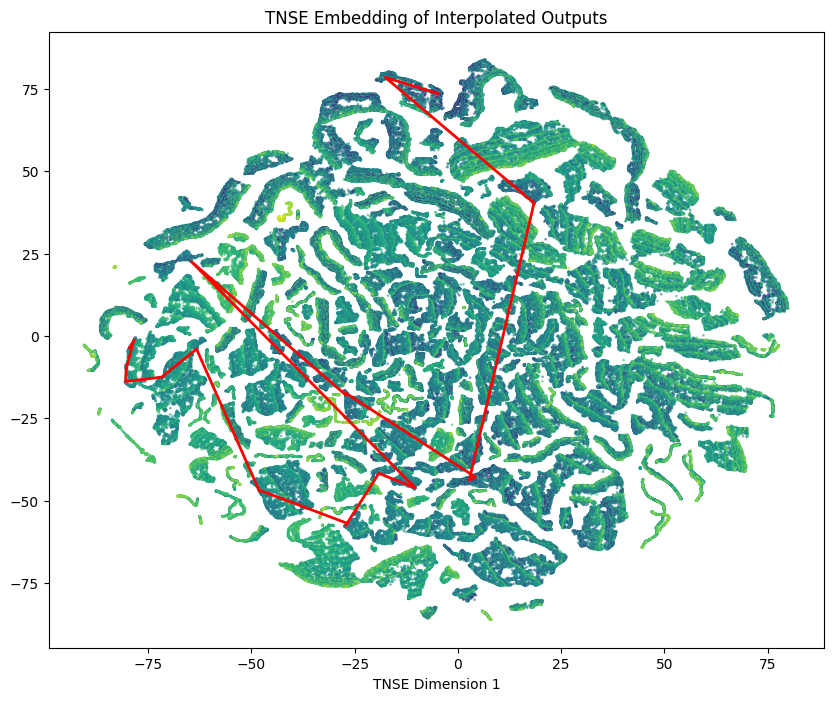

In [219]:
plt.figure(figsize=(10, 8))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], s=1, c=similarites, alpha=0.5)
plt.plot(embeddings_nn[:, 0], embeddings_nn[:, 1], color='red', linewidth=2)
plt.title("TNSE Embedding of Interpolated Outputs")
plt.xlabel("TNSE Dimension 1")